	Google Colaboratory
	Google Earth Engine
	GitHub	     

	Code Developed by
	Carlos Mendez
	Sebastian Palomino
	David Zamora

	First Part: Automated script to download Sentinel-1 images from a Google Earth Engine using GeeMap
	Second Part: Wetlands flooding extent and trends using SATellite data and Machine Learning WETSAT

	Please cite as follow:
	Palomino-Ángel, S., Méndez, C., Zamora, D., Santos, T., Prasad, S., and Piman, T. (2025). WetSAT-ML: Wetlands flooding extent and trends using SATellite data and Machine Learning (Version 1.0) [Data System]. Stockholm Environment Institute (SEI). https://github.com/sei-latam/WETSAT_v2.

# Automated donwload S1 images and apply Random Forest/Kmeans of WetSAT

# Install packages and libraries used in WETSAT and GeeMap

In [21]:
!pip install geemap # Install the geemap library for interactive mapping with Earth Engine
!pip install earthengine-api # Install the Earth Engine Python API
!pip install scikit-learn
!pip install rasterio
!pip install matplotlib
!pip install numpy
!pip install contextily
!pip install geopandas

# Import libraries and packages

In [22]:
## AI packages
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

## Geoprocessing packages
import ee #Earth Engine API
import geemap # GeeMap for visualization and mapping
import requests
import shutil
import geopandas as gpd
import webbrowser
import ipywidgets as widgets
from datetime import datetime

import os
import re
import random
import warnings
import gc
import joblib
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx
import seaborn as sns
import urllib.request
from rasterio.features import rasterize
from matplotlib.colors import ListedColormap
from shapely.geometry import box
from collections import Counter
from google.colab import files
from google.colab import data_table
from glob import glob
from rasterio.errors import NotGeoreferencedWarning
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

# Autentication in Google Colab and GEE

In [23]:
auth_url = ee.Authenticate(auth_mode='notebook')
webbrowser.open(auth_url)
ee.Authenticate()
ee.Initialize()

# Create basemaps and draw Area Of Interest (AOI)

In [40]:
MapAOI = geemap.Map()
MapAOI.setOptions('HYBRID')
MapAOI.add_draw_control()
MapAOI.setCenter(-74.0817, 4.6097, 8)

styles = {
    "OpenStreetMap": "OpenStreetMap",
    "Esri World Street Map": "Esri.WorldStreetMap",
    "Esri World Imagery": "Esri.WorldImagery",
    "Esri World Topo Map": "Esri.WorldTopoMap",
    "Esri World Gray Canvas": "Esri.WorldGrayCanvas",
    "Esri World Shaded Relief": "Esri.WorldShadedRelief",
    "Esri World Terrain": "Esri.WorldTerrain",
    "CartoDB DarkMatter": "CartoDB.DarkMatter",
    "CartoDB Positron": "CartoDB.Positron",
    "CartoDB Voyager": "CartoDB.Voyager",
    "OpenTopoMap": "OpenTopoMap"
}

style_dropdown = widgets.Dropdown(
    options=list(styles.keys()),
    value="Esri World Imagery",
    description="Basemap:"
)
def update_style(change):
    MapAOI.add_basemap(styles[change['new']])
style_dropdown.observe(update_style, names='value')

display(style_dropdown)
MapAOI

Dropdown(description='Basemap:', index=2, options=('OpenStreetMap', 'Esri World Street Map', 'Esri World Image…

Map(center=[4.6097, -74.0817], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDa…

In [41]:
aoi = MapAOI.user_roi
if aoi:
    print("AOI definido por el usuario:")
    print(aoi.getInfo())
else:
    print("No se ha dibujado ningún polígono todavía.")

AOI definido por el usuario:
{'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-75.629196, 9.239026], [-75.797081, 9.240382], [-75.799484, 9.022762], [-75.627136, 9.019371], [-75.629196, 9.239026]]]}


# Sentinel-1 SAR GRD: C-band Synthetic Aperture Radar Ground Range Detected

In [42]:
s1_collection = ee.ImageCollection("COPERNICUS/S1_GRD").filterBounds(aoi)
first_image = s1_collection.sort('system:time_start').first()
start_date = ee.Date(first_image.get('system:time_start')).format('YYYY-MM-dd').getInfo()
end_date = datetime.utcnow().strftime("%Y-%m-%d")

s1 = (s1_collection
      .filterDate(start_date, end_date)
      .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
      .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
      .sort('system:time_start', False))

orbit_filter_pass = 'DESCENDING'
if orbit_filter_pass is not None:
    s1 = s1.filter(ee.Filter.eq('orbitProperties_pass', orbit_filter_pass))

## Additional processes in S1 Images

In [43]:
def clip_bbox(image):
    return image.clip(aoi)

def gammamap(image, KERNEL_SIZE=7):
    enl = 5
    bandNames = image.bandNames().remove('angle')
    reducers = ee.Reducer.mean().combine(
        reducer2=ee.Reducer.stdDev(),
        sharedInputs=True
    )
    stats = image.select(bandNames).reduceNeighborhood(
        reducer=reducers,
        kernel=ee.Kernel.square(KERNEL_SIZE//2, 'pixels'),
        optimization='window'
    )
    meanBand = bandNames.map(lambda b: ee.String(b).cat('_mean'))
    stdDevBand = bandNames.map(lambda b: ee.String(b).cat('_stdDev'))

    z = stats.select(meanBand)
    sigz = stats.select(stdDevBand)
    ci = sigz.divide(z)

    cu = 1.0/(enl**0.5)
    cmax = (2**0.5) * cu

    cu = ee.Image.constant(cu)
    cmax = ee.Image.constant(cmax)
    enlImg = ee.Image.constant(enl)
    oneImg = ee.Image.constant(1)
    twoImg = ee.Image.constant(2)

    alpha = oneImg.add(cu.pow(2)).divide(ci.pow(2).subtract(cu.pow(2)))
    q = image.select(bandNames).expression(
        "z**2 * (z * alpha - enl - 1)**2 + 4 * alpha * enl * b() * z",
        {"z": z, "alpha": alpha, "enl": enl}
    )
    rHat = z.multiply(alpha.subtract(enlImg).subtract(oneImg)).add(q.sqrt()).divide(twoImg.multiply(alpha))

    zHat = z.updateMask(ci.lte(cu)).rename(bandNames)
    rHat = rHat.updateMask(ci.gt(cu)).updateMask(ci.lt(cmax)).rename(bandNames)
    x = image.select(bandNames).updateMask(ci.gte(cmax)).rename(bandNames)

    output = ee.ImageCollection([zHat, rHat, x]).sum()
    filteredBands = bandNames.map(lambda b: ee.String(b).cat('_filtered'))
    output = output.rename(filteredBands)

    return image.addBands(output)

## Apply additional processes

In [44]:
s1_preprocessed = (s1.map(lambda img: gammamap(img, 7))
                     .map(clip_bbox))

## Print S1 images in AOI

In [45]:
images_list = s1_preprocessed.toList(s1_preprocessed.size())
info_list = []
for i in range(s1_preprocessed.size().getInfo()):
    img = ee.Image(images_list.get(i))
    info = img.getInfo()
    info_list.append({
        'ID': info['id'],
        'Polarización': info['properties']['transmitterReceiverPolarisation']
    })

print("Imágenes Sentinel-1 preprocesadas disponibles en AOI:")
for info in info_list:
    print(info)

Imágenes Sentinel-1 preprocesadas disponibles en AOI:
{'ID': 'COPERNICUS/S1_GRD/S1A_IW_GRDH_1SDV_20260226T105005_20260226T105030_063389_07F657_E041', 'Polarización': ['VV', 'VH']}
{'ID': 'COPERNICUS/S1_GRD/S1C_IW_GRDH_1SDV_20260220T104906_20260220T104931_006438_00CF72_AF34', 'Polarización': ['VV', 'VH']}
{'ID': 'COPERNICUS/S1_GRD/S1A_IW_GRDH_1SDV_20260214T105005_20260214T105030_063214_07EFAC_999E', 'Polarización': ['VV', 'VH']}
{'ID': 'COPERNICUS/S1_GRD/S1C_IW_GRDH_1SDV_20260208T104906_20260208T104931_006263_00C956_5480', 'Polarización': ['VV', 'VH']}
{'ID': 'COPERNICUS/S1_GRD/S1A_IW_GRDH_1SDV_20260202T105006_20260202T105031_063039_07E92C_F92B', 'Polarización': ['VV', 'VH']}
{'ID': 'COPERNICUS/S1_GRD/S1C_IW_GRDH_1SDV_20260127T104907_20260127T104932_006088_00C368_5BDB', 'Polarización': ['VV', 'VH']}
{'ID': 'COPERNICUS/S1_GRD/S1A_IW_GRDH_1SDV_20260121T105006_20260121T105031_062864_07E2C0_63AA', 'Polarización': ['VV', 'VH']}
{'ID': 'COPERNICUS/S1_GRD/S1C_IW_GRDH_1SDV_20260115T104907_20260

## Visualize latest 3 images of S1 in the AOI

In [46]:
s1_10 = s1_preprocessed.limit(3)
images_list_10 = s1_10.toList(s1_10.size())

MapAOIS1 = geemap.Map()

for i in range(3):
    img = ee.Image(images_list_10.get(i))
    date_str = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    MapAOIS1.addLayer(img.select('VV'), {"min": -25, "max": 0}, f"VV {date_str}")
    MapAOIS1.addLayer(img.select('VV_filtered'), {"min": -25, "max": 0}, f"VV filtered {date_str}")
    MapAOIS1.addLayer(img.select('VH'), {"min": -30, "max": 0}, f"VH {date_str}")
    MapAOIS1.addLayer(img.select('VH_filtered'), {"min": -30, "max": 0}, f"VH filtered {date_str}")

MapAOIS1.addLayer(aoi, {"color":"darkblue", "opacity":0.7}, "Cobija SHP")
MapAOIS1.centerObject(aoi, 12)
MapAOIS1

Map(center=[9.129897428523439, -75.71309654371537], controls=(WidgetControl(options=['position', 'transparent_…

## Export S1 images to Google Colab Workspace

In [ ]:
os.makedirs("Sentinel1_Exports", exist_ok=True)

def download_images(collection, region):
    images_list = collection.toList(collection.size())
    n = collection.size().getInfo()

    for i in range(n):
        img = ee.Image(images_list.get(i))
        date_str = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd').getInfo()

        if 'VV' in img.bandNames().getInfo():
            url_vv = img.select('VV').getDownloadURL({
                'scale': 10,
                'crs': 'EPSG:4326',
                'region': region
            })
            r = requests.get(url_vv)
            with open(f"Sentinel1_Exports/S1_VV_SF_gammamap_{date_str}.tif", 'wb') as f:
                f.write(r.content)

        # Export VH band
        if 'VH' in img.bandNames().getInfo():
            url_vh = img.select('VH').getDownloadURL({
                'scale': 10,
                'crs': 'EPSG:4326',
                'region': region
            })
            r = requests.get(url_vh)
            with open(f"Sentinel1_Exports/S1_VH_SF_gammamap_{date_str}.tif", 'wb') as f:
                f.write(r.content)

download_images(s1_preprocessed, aoi)

## Calculate the PR index in new AOI

In [ ]:
## Access the VH Path
vh_path = "/content/WetSAT/VH"
## Access the VV Path
vv_path = "/content/WetSAT/VV"
## Create the PR Index path
pr_path = "/content/WetSAT/PR_index"

# Create output directory if it doesn't exist
os.makedirs(pr_path, exist_ok=True)

# List VH and VV files (assuming matching filenames)
vh_files = sorted([f for f in os.listdir(vh_path) if f.endswith(".tif")]) # Search files ending with .tif
vv_files = sorted([f for f in os.listdir(vv_path) if f.endswith(".tif")]) # Search files ending with .tif

# Loop through files and compute PR index scaled between 0 and 1
for vh_file, vv_file in zip(vh_files, vv_files):
    # Read the vh_files and vv_files
    with rasterio.open(os.path.join(vh_path, vh_file)) as vh_src, \
         rasterio.open(os.path.join(vv_path, vv_file)) as vv_src:

        vh = vh_src.read(1).astype("float32") # Converts the data to 32-bit float
        vv = vv_src.read(1).astype("float32") # Converts the data to 32-bit float

        pr_index_diff = vh - vv  # Compute PR index as difference

        # Save PR index difference
        profile = vh_src.profile
        profile.update(dtype="float32", count=1)

        pr_filename = f"PR_diff_{vh_file}"
        with rasterio.open(os.path.join(pr_path, pr_filename), "w", **profile) as dst:
            dst.write(pr_index_diff, 1)

print("PR index (VH - VV) computation complete.")

PR index (VH - VV) computation complete.


# Import the Random Forest Model and Labels/Encoders

In [ ]:
# Create backup from GitHub to import Random Forest
# Load Random Forest Model
model_url = "https://raw.githubusercontent.com/sei-latam/WETSAT_v2/main/2_Modelling_WETSAT_Google_Colab/Model_Random_Forest.pkl"
urllib.request.urlretrieve(model_url, "Model_Random_Forest.pkl")
rf_model = joblib.load("Model_Random_Forest.pkl")

# Load encoders
encoder_url = "https://raw.githubusercontent.com/sei-latam/WETSAT_v2/main/2_Modelling_WETSAT_Google_Colab/Labels_Random_Forest.pkl"
urllib.request.urlretrieve(encoder_url, "Labels_Random_Forest.pkl")
le = joblib.load("Labels_Random_Forest.pkl")

### Prepare data and verify size of VH,VV and PR

In [ ]:
vv_files = sorted([f for f in os.listdir(vv_path) if f.endswith(".tif")])
vh_files = sorted([f for f in os.listdir(vh_path) if f.endswith(".tif")])
pr_files = sorted([f for f in os.listdir(pr_path) if f.endswith(".tif")])

assert len(vv_files) == len(vh_files) == len(pr_files), "The size of VV, VH and PR must be equal (size)"

In [ ]:
output_path = "/content/WetSAT/RF_Classification"

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

## Start Classifications and Maps

In [ ]:
def predict_and_save(vv_file, vh_file, pr_file, model, encoder, index):
    with rasterio.open(os.path.join(vv_path, vv_file)) as vv_src, \
         rasterio.open(os.path.join(vh_path, vh_file)) as vh_src, \
         rasterio.open(os.path.join(pr_path, pr_file)) as pr_src:

        vv = vv_src.read(1)
        vh = vh_src.read(1)
        pr = pr_src.read(1)

        assert vv.shape == vh.shape == pr.shape, "size verification"

        # Detect NoData mask (assuming all bands share the same mask)
        nodata_val = vv_src.nodata
        valid_mask = (vv != nodata_val) & (vh != nodata_val) & (pr != nodata_val)

        stacked = np.stack([vh, vv, pr], axis=-1)
        shape = stacked.shape[:2]
        flat_pixels = stacked.reshape(-1, 3)

        # Apply mask to valid pixels
        flat_mask = valid_mask.flatten()
        valid_pixels = flat_pixels[flat_mask]

        # Predict only on valid pixels
        pred_encoded = model.predict(valid_pixels)

        # Create full prediction array filled with nodata (255)
        pred_numeric = np.full(flat_mask.shape, 255, dtype=np.uint8)
        pred_numeric[flat_mask] = pred_encoded
        pred_numeric = pred_numeric.reshape(shape)

        # Stored classification using the original name (for example from VV path)
        base_name = os.path.splitext(vv_file)[0]   # remove temporal extension of .tif

        output_path_rf = f"Classification_RF_{base_name}.tif"

        # Save prediction raster
        profile = vv_src.profile
        profile.update(dtype=rasterio.uint8, count=1, nodata=255)

        with rasterio.open(os.path.join(output_path, output_path_rf), "w", **profile) as dst:
            dst.write(pred_numeric, 1)

        print(f"✅ Image stored as: {output_path_rf}")

## Looping to create maps and rasters

In [ ]:
for i in range(len(vv_files)):
    predict_and_save(vv_files[i], vh_files[i], pr_files[i], rf_model, le, i)

✅ Image stored as: Classification_RF_20180101_VV.tif
✅ Image stored as: Classification_RF_20180113_VV.tif
✅ Image stored as: Classification_RF_20180125_VV.tif
✅ Image stored as: Classification_RF_20180206_VV.tif
✅ Image stored as: Classification_RF_20180218_VV.tif


## Report of areas (km2) by classifications

### Classification report (table)

In [ ]:
def area_by_class_meters(raster_path, nodata=255, class_map=None):
    with rasterio.open(raster_path) as src:
        data = src.read(1)
        transform = src.transform
        res_x = transform.a
        res_y = -transform.e
        pixel_area_m2 = abs(res_x) * abs(res_y)

        # Use Valid Mask
        if src.nodata is not None:
            nodata = src.nodata
        valid = data != nodata

        # Calculate number of pixels by label
        vals = data[valid].ravel()
        counts = Counter(vals.tolist())

    # Base name of files
    raster_name = os.path.basename(raster_path)

    # Convert to km² and store data
    records = []
    for code, n in counts.items():
        area_km2 = (n * pixel_area_m2) / 1_000_000.0
        etiqueta = class_map.get(code, str(code)) if class_map else str(code)
        records.append({
            "archivo": raster_name,
            "code": code,
            "etiqueta": etiqueta,
            "pixeles": n,
            "area_km2": area_km2
        })

    df = pd.DataFrame(records).sort_values("code").reset_index(drop=True)
    total_km2 = df["area_km2"].sum()
    return df, total_km2

### Export classification report to CSV

In [ ]:
class_map = {i: cls for i, cls in enumerate(le.classes_)}

# Search all .tif files of classification
paths = sorted(glob.glob("/content/WetSAT/RF_Classification/Classification_RF_*.tif"))

resumen = []
for p in paths:
    df_area, total = area_by_class_meters(p, nodata=255, class_map=class_map)
    resumen.append(df_area)

# Concatenate all results
resumen_df = pd.concat(resumen, ignore_index=True)

# show the final dataframe
print(resumen_df)

# Export dataframe to csv file
resumen_df.to_csv("area_by_class.csv", index=False)
print("📄 csv file exported as 'area_by_class.csv'")

                              archivo  code etiqueta  pixeles   area_km2
0   Classification_RF_20180101_VV.tif     0      e11     6886     6.1974
1   Classification_RF_20180101_VV.tif     2      e13    15130    13.6170
2   Classification_RF_20180101_VV.tif     3      e21  4224830  3802.3470
3   Classification_RF_20180101_VV.tif     4      e22  5355652  4820.0868
4   Classification_RF_20180101_VV.tif     5      e23   248052   223.2468
5   Classification_RF_20180113_VV.tif     0      e11     5082     4.5738
6   Classification_RF_20180113_VV.tif     1      e12        4     0.0036
7   Classification_RF_20180113_VV.tif     2      e13     9463     8.5167
8   Classification_RF_20180113_VV.tif     3      e21  4261611  3835.4499
9   Classification_RF_20180113_VV.tif     4      e22  5407889  4867.1001
10  Classification_RF_20180113_VV.tif     5      e23   166527   149.8743
11  Classification_RF_20180125_VV.tif     0      e11     6621     5.9589
12  Classification_RF_20180125_VV.tif     1      e1

## Visualizing classification and maps

In [ ]:
def visualizar_pronosticos_coloreado(folder_path, label_encoder, label_colors, nodata=255, images_per_fig=6):
    tif_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.tif')])
    num_files = len(tif_files)

    # Transform integer and numbers to labels
    code_to_label = {i: label for i, label in enumerate(label_encoder.classes_)}
    cmap_colors = [label_colors.get(code_to_label[i], "#FFFFFF") for i in range(len(code_to_label))]
    cmap = ListedColormap(cmap_colors)

    for i in range(0, num_files, images_per_fig):
        fig, axes = plt.subplots(1, images_per_fig, figsize=(18, 3))
        axes = axes.flatten()

        for j in range(images_per_fig):
            idx = i + j
            if idx < num_files:
                filename = tif_files[idx]
                with rasterio.open(os.path.join(folder_path, filename)) as src:
                    data = src.read(1)
                    if src.nodata is not None:
                        nodata = src.nodata
                    data = np.ma.masked_equal(data, nodata)

                    im = axes[j].imshow(data, cmap=cmap, interpolation='none', vmin=0, vmax=len(code_to_label)-1)
                    axes[j].set_title(filename, fontsize=8)
                    axes[j].axis('off')

                    cbar = fig.colorbar(im, ax=axes[j], shrink=1.0, ticks=np.arange(len(code_to_label)))
                    cbar.ax.set_yticklabels([code_to_label[i] for i in range(len(code_to_label))])
            else:
                axes[j].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

### Legend and conventions

In [ ]:
label_colors = {
    'e11': '#A7D98D',  # Non-water – Sparse vegetation
    'e12': '#E8D8A8',  # Non-water – No vegetation
    'e13': '#2E7D32',  # Non-water – Dense vegetation
    'e21': '#76C9CC',  # Water – Sparse vegetation
    'e22': '#1E88E5',  # Water – No vegetation (open water)
    'e23': '#006D6F'   # Water – Dense vegetation
}

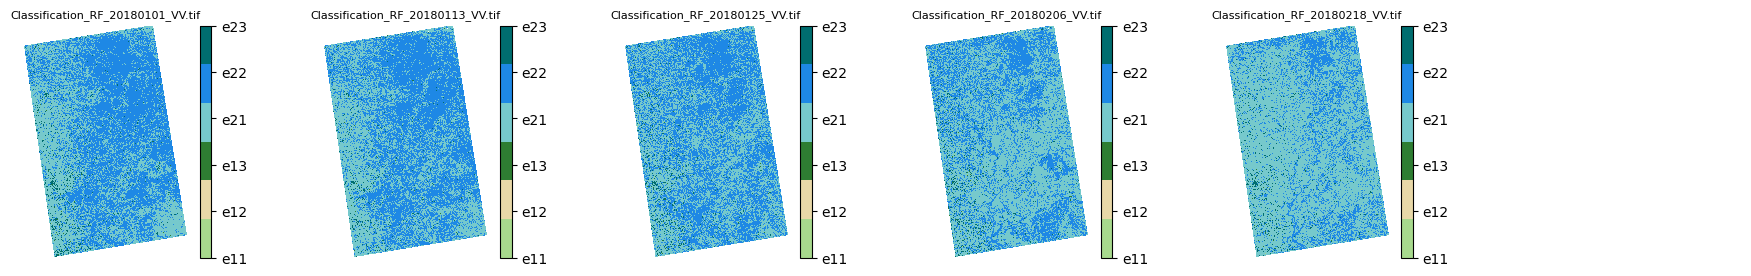

In [ ]:
visualizar_pronosticos_coloreado("/content/WetSAT/RF_Classification", label_encoder=le, label_colors=label_colors)